<a href="https://colab.research.google.com/github/JayRiv25/InflacionCOVID/blob/main/Copy_of_Inflaci%C3%B3n_Post_COVID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
#Carga de datos
df = pd.read_csv("/content/covid_global.csv", low_memory=False)
df.head(100)

,country,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index
0,USA,2020-01,0.33,5.76,34.44,0.34,5.97,10558.0,69.95,94.29,3.66
1,USA,2020-02,4.12,4.33,44.75,0.02,5.80,6952.0,71.03,78.60,3.91
2,USA,2020-03,2.75,4.24,52.80,0.30,7.45,10244.0,71.00,102.91,3.70
3,USA,2020-04,4.36,4.52,39.19,2.28,5.23,9989.0,83.52,110.92,3.23
4,USA,2020-05,2.73,3.17,41.09,3.05,5.96,7982.0,70.10,86.53,3.94
...,...,...,...,...,...,...,...,...,...,...,...
95,VNM,2022-12,4.22,2.03,136.94,3.17,6.16,11070.0,92.17,140.10,1.19
96,VNM,2023-01,5.69,3.54,63.97,1.96,5.22,12914.0,98.51,129.84,1.13
97,VNM,2023-02,4.94,2.43,70.75,6.69,5.58,15715.0,95.73,126.41,1.26
98,VNM,2023-03,5.36,2.91,81.56,5.76,5.65,15773.0,93.67,128.33,1.75


In [3]:
#Conviertir 'date' para poder tomar separadamente el año  y el mes
df['date'] = pd.to_datetime(df['date'])
df['año'] = df['date'].dt.year
df['mes'] = df['date'].dt.month

#Verificar faltalntes
df.isnull().sum()

#Estatus básicos
df.describe()

,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index,año,mes
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-17 22:14:00.095999744,4.175859,2.559960,75.026843,2.476658,5.514667,11947.973270,46.908610,119.597836,1.939958,2022.002540,6.512050
min,2020-01-01 00:00:00,-1.999003,-2.810000,22.640000,-4.580000,2.000000,3858.000000,2.340000,70.770000,1.000000,2020.000000,1.000000
25%,2021-03-01 00:00:00,3.173408,1.190000,62.860000,1.090000,4.710000,10060.000000,22.610000,107.180000,1.240000,2021.000000,4.000000
50%,2022-07-01 00:00:00,4.226506,2.590000,75.200000,2.520000,5.500000,11788.000000,42.360000,119.830000,1.670000,2022.000000,7.000000
75%,2023-10-01 00:00:00,5.202572,3.940000,85.680000,3.940000,6.340000,13690.000000,73.310000,132.420000,2.270000,2023.000000,10.000000
max,2024-12-01 00:00:00,9.634656,8.130000,153.770000,10.090000,9.140000,21241.000000,104.950000,165.300000,4.880000,2024.000000,12.000000
std,NaN,1.463516,1.856475,24.380590,2.156974,1.199608,2744.008662,30.259072,17.118195,0.912450,1.416423,3.451709


In [4]:
#Se cargan los nuevos datos (año y mes están separados)
df.head(100)

,country,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index,año,mes
0,USA,2020-01-01,0.33,5.76,34.44,0.34,5.97,10558.0,69.95,94.29,3.66,2020,1
1,USA,2020-02-01,4.12,4.33,44.75,0.02,5.80,6952.0,71.03,78.60,3.91,2020,2
2,USA,2020-03-01,2.75,4.24,52.80,0.30,7.45,10244.0,71.00,102.91,3.70,2020,3
3,USA,2020-04-01,4.36,4.52,39.19,2.28,5.23,9989.0,83.52,110.92,3.23,2020,4
4,USA,2020-05-01,2.73,3.17,41.09,3.05,5.96,7982.0,70.10,86.53,3.94,2020,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,VNM,2022-12-01,4.22,2.03,136.94,3.17,6.16,11070.0,92.17,140.10,1.19,2022,12
96,VNM,2023-01-01,5.69,3.54,63.97,1.96,5.22,12914.0,98.51,129.84,1.13,2023,1
97,VNM,2023-02-01,4.94,2.43,70.75,6.69,5.58,15715.0,95.73,126.41,1.26,2023,2
98,VNM,2023-03-01,5.36,2.91,81.56,5.76,5.65,15773.0,93.67,128.33,1.75,2023,3


In [5]:
#Cantidad de filas y columnas
df.shape

(100000, 13)

In [6]:
#Se busca si hay nulos
df.isnull().any().any()

np.False_

In [7]:
#Cantidad de nulos por columna
df.isnull().sum()

,0
country,0
date,0
inflation_rate,0
interest_rate,0
oil_price,0
gdp_growth,0
unemployment_rate,0
money_supply_m2,0
exchange_rate_usd,0
food_price_index,0


In [8]:
#Agrupación de las columnas por tipo de datos
tipos = df.columns.to_series().groupby(df.dtypes).groups

#Conociendo la lista de columnas categóricas
ctext = tipos[np.dtype('object')]
len(ctext) #Cantidad de columnas con datos categóricos

1

In [9]:
#Conociendo la lista de columnas numéricas
columnas = df.columns
cnum = list(set(columnas) - set(ctext))
len(cnum)

12

In [10]:
#Guardando el dataset preprocesado
df.to_csv("covid_global_procesado.csv", index=False)

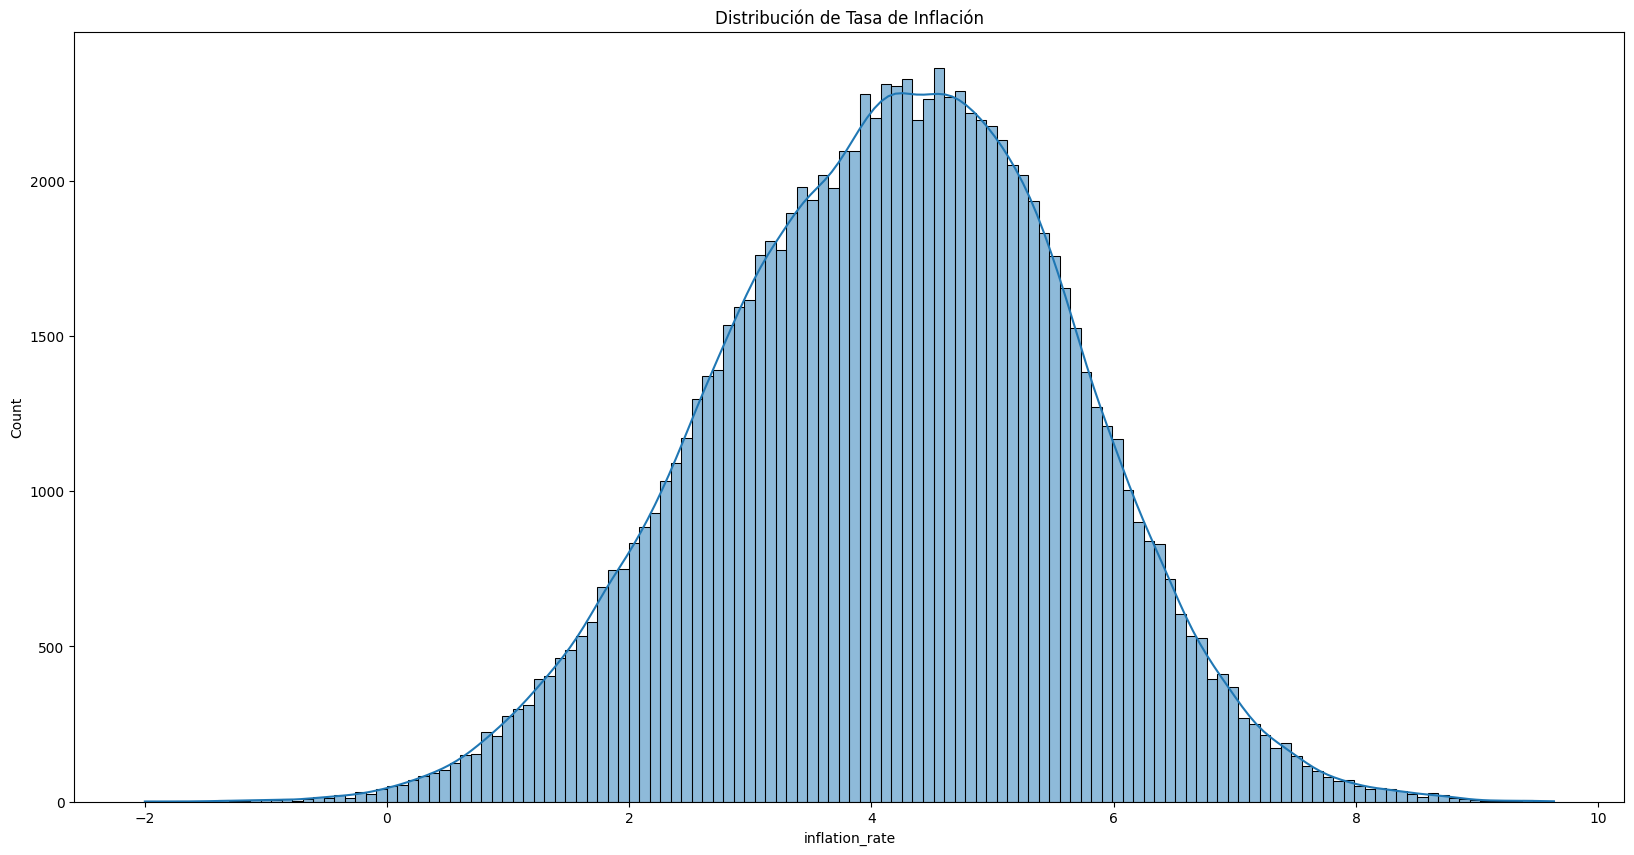

In [11]:
#Distribución de inflación
plt.figure(figsize=(20,10))
sb.histplot(df['inflation_rate'], kde=True)
plt.title("Distribución de Tasa de Inflación")
plt.show()

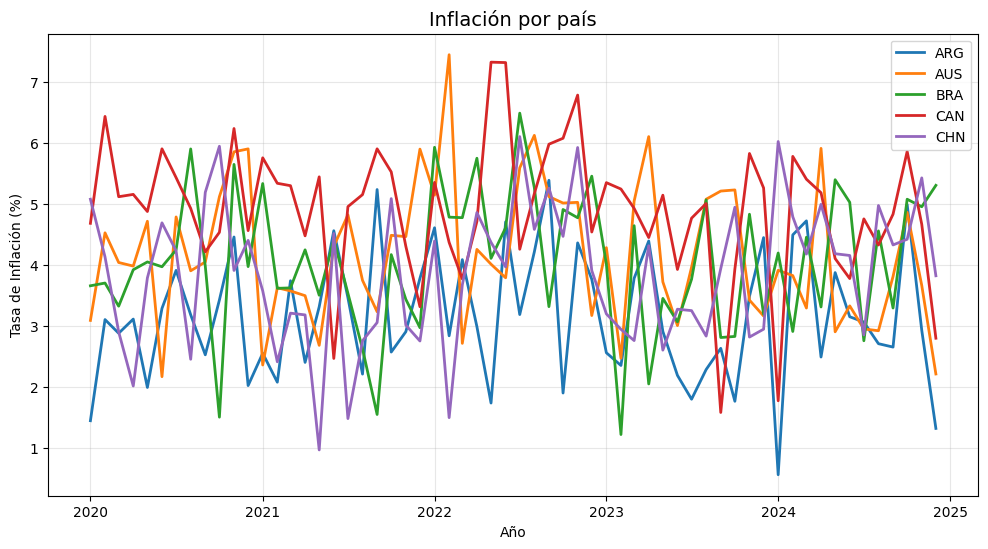

In [12]:
#Inflación por país
df_plot = df.groupby(['country', 'date'], as_index=False)['inflation_rate'].mean()
top_countries = df_plot['country'].value_counts().index[:5]

plt.figure(figsize=(12,6))

for c in top_countries:
    temp = df_plot[df_plot['country'] == c]
    plt.plot(temp['date'], temp['inflation_rate'], linewidth=2)



plt.title("Inflación por país", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Tasa de Inflación (%)")
plt.legend(top_countries)
plt.grid(True, alpha=0.3)
plt.show()

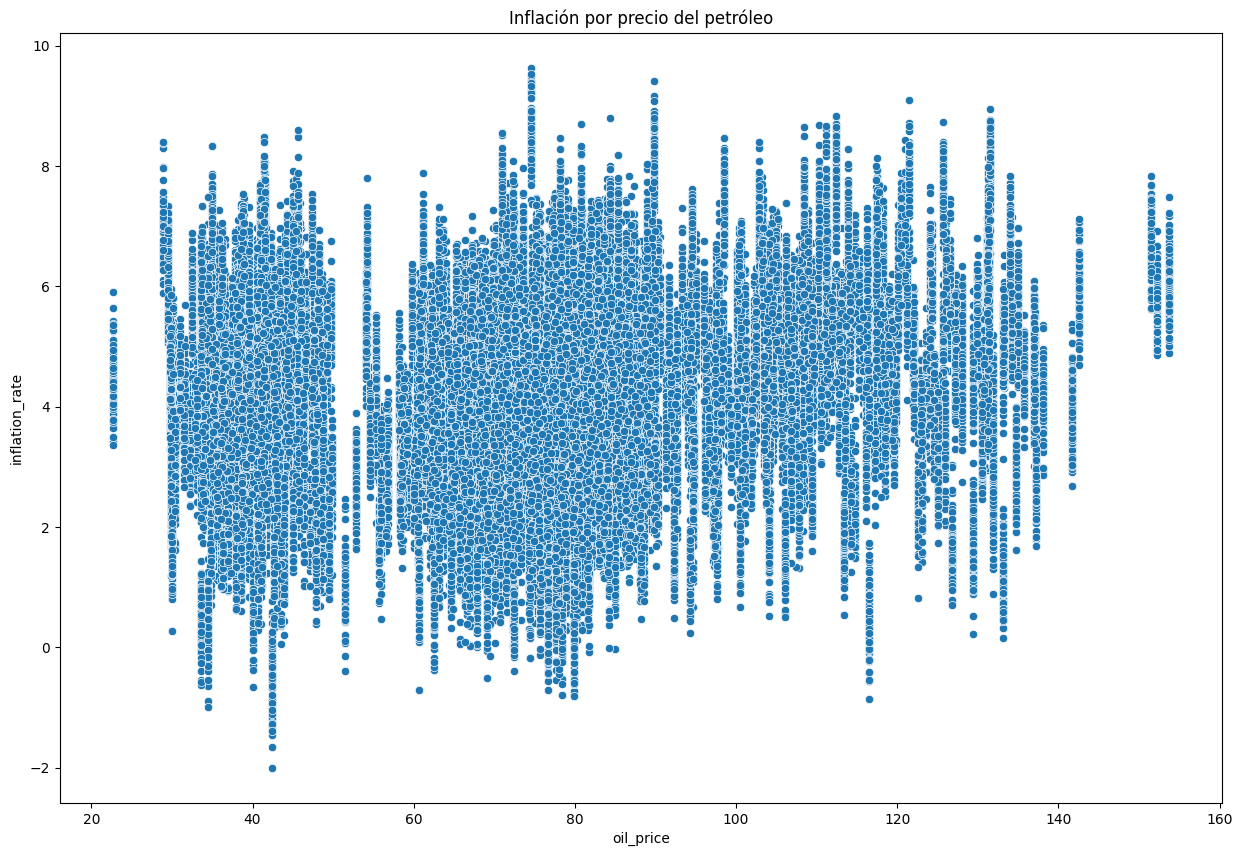

In [13]:
#inflación del petróleo
plt.figure(figsize=(15,10))
sb.scatterplot(x='oil_price', y='inflation_rate', data=df)
plt.title("Inflación por precio del petróleo")
plt.show()

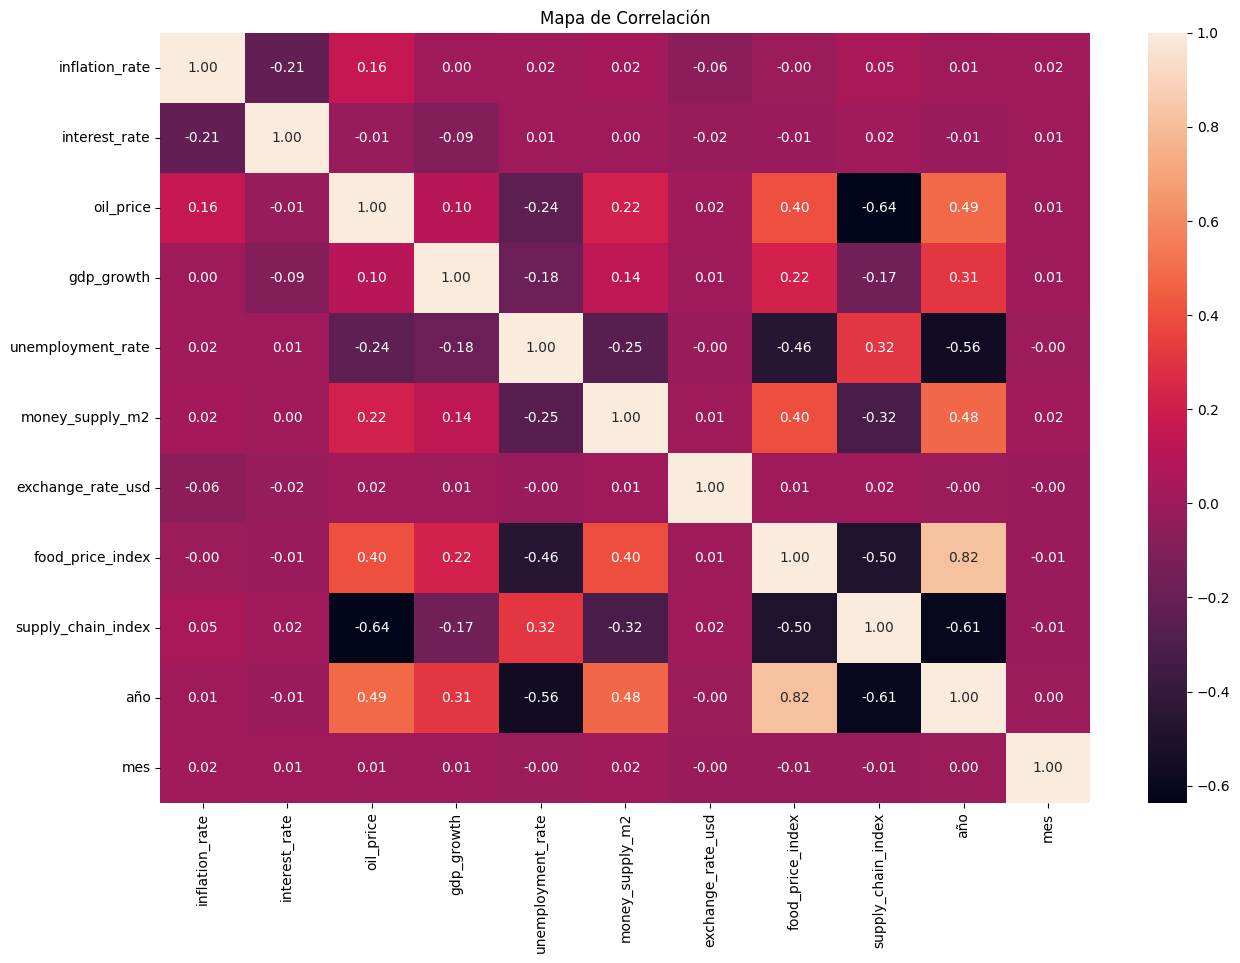

In [14]:
#Mapa de Correlación (Heatmap)
plt.figure(figsize=(15,10))
sb.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Mapa de Correlación")
plt.show()